## Objective Fucntion

In [1]:
# To be adjusted
def calculate_suitability(row, w0=0.7, w1=0.3, w2=-0.2, w3=-0.2):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']


## Genetic Algo

In [2]:
import pandas as pd
import numpy as np
import random

def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['suitability_score'].sum()

        # --- Grid proximity penalty ---
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111  # 1° lat ≈ 111 km
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 200:  # Only penalize close points (<5 km)
                    penalty += 1 / (distance_km + 1e-6)

        lambda_penalty = 100  # Weight for penalty
        return suitability_score - lambda_penalty * penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate((parent1[:point], parent2[point:]))
        child2 = np.concatenate((parent2[:point], parent1[point:]))
        return child1, child2

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]

        selected = selection(population, fitnesses)
        next_generation = []

        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])

        population = next_generation[:population_size]

        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")

        fitness_scores.append(best_fitness)

    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_ga_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_ga_penalty.csv'")

    return best_individual, best_fitness, fitness_scores

def run_genetic_algo():
    file_path = r"C:\Users\aya20\Desktop\6.semester\optimization\optProjCode\lat_lon_avg_score.csv"
    df_input = pd.read_csv(file_path)

    # Rename 'score' column to 'suitability_score' if needed
    if 'suitability_score' not in df_input.columns:
        if 'score' in df_input.columns:
            df_input = df_input.rename(columns={'score': 'suitability_score'})
        elif 'avg_score' in df_input.columns:
            df_input = df_input.rename(columns={'avg_score': 'suitability_score'})

    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df_input,
        population_size=50,
        generations=100,
        mutation_rate=0.1,
        num_points=20,
        verbose=True
    )
    return best_assignment, best_fitness, fitness_scores

# Run
if __name__ == "__main__":
    run_genetic_algo()


Generation 1, Best Fitness: -1.3729
Generation 11, Best Fitness: 2.4750
Generation 21, Best Fitness: 5.2646
Generation 31, Best Fitness: 6.4332
Generation 41, Best Fitness: 6.4332
Generation 51, Best Fitness: 6.7537
Generation 61, Best Fitness: 6.7969
Generation 71, Best Fitness: 6.9496
Generation 81, Best Fitness: 7.7656
Generation 91, Best Fitness: 7.8506
Best 20 points saved to 'best_20_points_ga_penalty.csv'


C:\Users\aya20\AppData\Local\Temp\ipykernel_6916\771306628.py:7: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


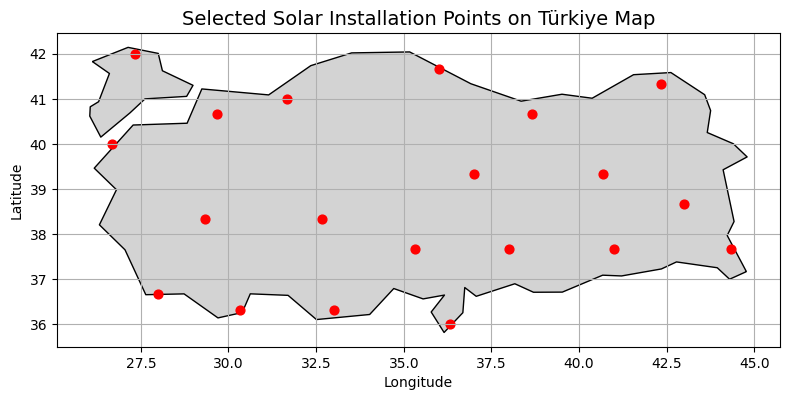

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load Türkiye shapefile from GeoPandas built-in dataset or a local file
# This uses Natural Earth low-res countries dataset
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
turkey = world[world.name == "Turkey"]

# Load the selected points
selected_points = pd.read_csv('best_20_points_ga_penalty.csv')

# Convert points to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    selected_points,
    geometry=gpd.points_from_xy(selected_points.lon, selected_points.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')
gdf_points.plot(ax=ax, color='red', markersize=40)

plt.title("Selected Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
# Load the dataset with lat, lon, and avg_score
df = pd.read_csv("lat_lon_avg_score.csv")

# Select the top 20 points with the highest avg_score
top_20_points = df.nlargest(20, 'avg_score')

# Save to CSV
output_path_top20 = "top_20_points_direct.csv"
top_20_points.to_csv(output_path_top20, index=False)

output_path_top20


'top_20_points_direct.csv'

## Simulated Annealing

In [6]:
import pandas as pd
import numpy as np
import random
import math

def calculate_suitability(row, w0=0.7, w1=0.2, w2=-0.1, w3=-0.1):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']

def optimize_solar_sites(df, budget=20, max_iterations=1000, initial_temp=1000, cooling_rate=0.003, verbose=False):
    df = df.copy()
    df['suitability_score'] = df.apply(calculate_suitability, axis=1)

    num_points = budget
    current_solution = np.random.choice(df.index, num_points, replace=False)
    current_cost = -df.loc[current_solution, 'suitability_score'].sum()
    best_solution = current_solution.copy()
    best_cost = current_cost
    temperature = initial_temp

    for i in range(max_iterations):
        new_solution = current_solution.copy()
        d1_idx = random.randint(0, num_points - 1)
        d2 = random.choice([idx for idx in df.index if idx not in new_solution])
        new_solution[d1_idx] = d2

        new_cost = -df.loc[new_solution, 'suitability_score'].sum()

        if new_cost < current_cost or random.uniform(0, 1) < math.exp((current_cost - new_cost) / temperature):
            current_solution = new_solution.copy()
            current_cost = new_cost

            if current_cost < best_cost:
                best_solution = current_solution.copy()
                best_cost = current_cost

        temperature *= (1 - cooling_rate)

        if verbose and i % 100 == 0:
            print(f"Iteration {i + 1}, Current Fitness: {-current_cost}, Best Fitness: {-best_cost}")

    best_points = df.loc[best_solution]
    best_points.to_csv('best_20_points_optimized.csv', index=False)
    print("Best 20 grid points saved to 'best_20_points_optimized.csv'")

    # Print detailed grid point info
    print("\nSelected Grid Points:")
    print(best_points[['lat', 'lon', 'suitability_score']])

    best_fitness = -best_cost / num_points
    return best_points, best_fitness

def run_optimize_solar_sites():
    df_input = pd.read_csv('nasa_annual_summary_l2_normalized_scaled.csv')
    best_points, best_fitness = optimize_solar_sites(
        df_input,
        budget=20,
        max_iterations=1000,
        initial_temp=1000,
        cooling_rate=0.003,
        verbose=True
    )
    print("Best fitness (average score):", best_fitness)
    return best_points, best_fitness

if __name__ == "__main__":
    run_optimize_solar_sites()


Iteration 1, Current Fitness: 5.292800000000001, Best Fitness: 5.302200000000001
Iteration 101, Current Fitness: 5.307600000000001, Best Fitness: 5.340400000000002
Iteration 201, Current Fitness: 5.313300000000001, Best Fitness: 5.3426
Iteration 301, Current Fitness: 5.2775, Best Fitness: 5.3563
Iteration 401, Current Fitness: 5.2926, Best Fitness: 5.3657
Iteration 501, Current Fitness: 5.3187999999999995, Best Fitness: 5.3657
Iteration 601, Current Fitness: 5.3058000000000005, Best Fitness: 5.3657
Iteration 701, Current Fitness: 5.3176000000000005, Best Fitness: 5.3657
Iteration 801, Current Fitness: 5.315600000000001, Best Fitness: 5.3657
Iteration 901, Current Fitness: 5.3109, Best Fitness: 5.3657
Best 20 grid points saved to 'best_20_points_optimized.csv'

Selected Grid Points:
       lat    lon  suitability_score
348  41.10  28.33             0.2668
601  41.18  28.57             0.2671
81   40.98  29.17             0.2765
574  41.16  29.44             0.2612
809  41.30  28.09     

## Particle Swarm

In [7]:
import pandas as pd
import numpy as np
import random
import math

def calculate_suitability(row, w0=0.7, w1=0.2, w2=-0.1, w3=-0.1):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']

def run_pso_solar_sites():
    df_input = pd.read_csv('nasa_annual_summary_l2_normalized_scaled.csv')
    df_input['suitability_score'] = df_input.apply(calculate_suitability, axis=1)

    N = len(df_input)
    swarmsize = 100
    maxiter = 100
    c1 = 2.0
    c2 = 2.0
    w = 0.7
    budget = 20

    # Initialize particles: each particle is an array of selected indices
    particles = [np.random.choice(N, budget, replace=False) for _ in range(swarmsize)]
    velocities = [np.zeros(budget) for _ in range(swarmsize)]

    def fitness_function(indices):
        return df_input.loc[indices, 'suitability_score'].sum()

    pbest = particles.copy()
    pbest_fitness = np.array([fitness_function(p) for p in particles])
    gbest = particles[np.argmax(pbest_fitness)].copy()
    gbest_fitness = np.max(pbest_fitness)

    for iteration in range(maxiter):
        for i in range(swarmsize):
            fitness = fitness_function(particles[i])
            if fitness > pbest_fitness[i]:
                pbest[i] = particles[i].copy()
                pbest_fitness[i] = fitness
                if fitness > gbest_fitness:
                    gbest = particles[i].copy()
                    gbest_fitness = fitness

        for i in range(swarmsize):
            # Update velocity (conceptually, swap indices toward best)
            new_indices = particles[i].copy()
            swap_idx = random.randint(0, budget - 1)
            if gbest[swap_idx] not in new_indices:
                new_indices[swap_idx] = gbest[swap_idx]
            particles[i] = np.unique(new_indices)
            if len(particles[i]) < budget:
                additional = np.random.choice([idx for idx in range(N) if idx not in particles[i]], budget - len(particles[i]), replace=False)
                particles[i] = np.concatenate([particles[i], additional])

        if iteration % 10 == 0:
            print(f"Iteration {iteration + 1}, Best Fitness: {gbest_fitness}")

    best_points = df_input.loc[gbest]
    best_points.to_csv('best_pso_points.csv', index=False)
    print("Best PSO grid points saved to 'best_pso_points.csv'")
    print("\nSelected Grid Points:")
    print(best_points[['lat', 'lon', 'suitability_score']])
    best_fitness = gbest_fitness / budget
    print("Best fitness (average score):", best_fitness)
    return best_points, best_fitness

if __name__ == "__main__":
    run_pso_solar_sites()


Iteration 1, Best Fitness: 5.385700000000002
Iteration 11, Best Fitness: 5.391200000000001
Iteration 21, Best Fitness: 5.398300000000001
Iteration 31, Best Fitness: 5.409700000000002
Iteration 41, Best Fitness: 5.412500000000001
Iteration 51, Best Fitness: 5.421800000000002
Iteration 61, Best Fitness: 5.425300000000002
Iteration 71, Best Fitness: 5.425300000000002
Iteration 81, Best Fitness: 5.431100000000001
Iteration 91, Best Fitness: 5.431600000000001
Best PSO grid points saved to 'best_pso_points.csv'

Selected Grid Points:
       lat    lon  suitability_score
4    40.84  29.35             0.2765
66   40.98  28.63             0.2823
67   40.98  28.66             0.2823
73   40.98  28.84             0.2823
75   40.98  28.90             0.2823
77   40.98  29.05             0.2804
90   40.98  29.44             0.2765
225  41.06  28.42             0.2668
235  41.06  28.72             0.2671
359  41.10  28.66             0.2671
429  41.12  28.84             0.2671
490  41.14  28.78     

## Comparison